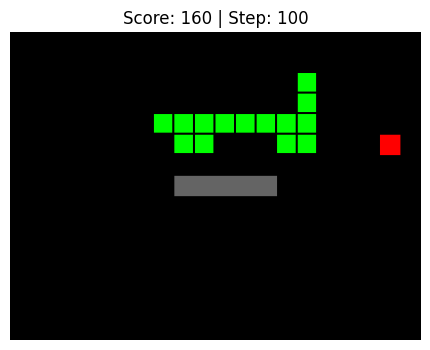

Game finished! Final Score: 160


In [2]:
# 1. Install necessary libraries for headless rendering
!pip install pygame matplotlib clear_output > /dev/null 2>&1

import pygame
import random
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Force Pygame to use the dummy video driver (Headless Mode)
os.environ["SDL_VIDEODRIVER"] = "dummy"

# 2. Initialize Pygame
pygame.init()

# Window dimensions
WINDOW_WIDTH = 400  # Scaled down slightly for better notebook rendering
WINDOW_HEIGHT = 300
CELL_SIZE = 20

# Colors (RGB)
COLOR_BLACK = (0, 0, 0)
COLOR_WHITE = (255, 255, 255)
COLOR_GREEN = (0, 255, 0)       # Snake
COLOR_RED = (255, 0, 0)         # Regular fruit
COLOR_YELLOW = (255, 255, 0)     # Special fruit
COLOR_GREY = (100, 100, 100)     # Obstacles

# Set up display surface
screen = pygame.display.set_mode((WINDOW_WIDTH, WINDOW_HEIGHT))
pygame.display.set_caption("AI Lab - Colab Automated Snake Game")

# Main Game Loop Function
def game_loop_colab(max_steps=100):
    # Snake Initial Position & Body
    snake_x = 100
    snake_y = 100
    snake_body = [[snake_x, snake_y], [snake_x - CELL_SIZE, snake_y], [snake_x - (2 * CELL_SIZE), snake_y]]
    direction = "RIGHT"

    score = 0
    game_over = False
    steps = 0

    def generate_food_pos():
        x = random.randrange(1, (WINDOW_WIDTH // CELL_SIZE) - 1) * CELL_SIZE
        y = random.randrange(1, (WINDOW_HEIGHT // CELL_SIZE) - 1) * CELL_SIZE
        return [x, y]

    food_pos = generate_food_pos()
    yellow_food_pos = None

    obstacles = [
        [160, 140], [180, 140], [200, 140], [220, 140], [240, 140]
    ]

    while not game_over and steps < max_steps:
        steps += 1

        # --- 3. AUTOMATED AI AGENT POLICY ---
        # Target either yellow or red food
        target = yellow_food_pos if yellow_food_pos else food_pos

        # Simple heuristic: Move towards the target while avoiding immediate self/wall collision
        possible_moves = []
        if direction != "DOWN": possible_moves.append(("UP", snake_x, snake_y - CELL_SIZE))
        if direction != "UP": possible_moves.append(("DOWN", snake_x, snake_y + CELL_SIZE))
        if direction != "RIGHT": possible_moves.append(("LEFT", snake_x - CELL_SIZE, snake_y))
        if direction != "LEFT": possible_moves.append(("RIGHT", snake_x + CELL_SIZE, snake_y))

        best_move = direction
        min_distance = float('inf')

        for move, next_x, next_y in possible_moves:
            # Check for wall or obstacle collision
            if next_x < 0 or next_x >= WINDOW_WIDTH or next_y < 0 or next_y >= WINDOW_HEIGHT:
                continue
            if [next_x, next_y] in obstacles or [next_x, next_y] in snake_body:
                continue

            # Manhattan distance calculation
            dist = abs(next_x - target[0]) + abs(next_y - target[1])
            if dist < min_distance:
                min_distance = dist
                best_move = move

        direction = best_move

        # Move Snake Head
        if direction == "UP": snake_y -= CELL_SIZE
        elif direction == "DOWN": snake_y += CELL_SIZE
        elif direction == "LEFT": snake_x -= CELL_SIZE
        elif direction == "RIGHT": snake_x += CELL_SIZE

        snake_body.insert(0, [snake_x, snake_y])

        # Scoring Logic
        if snake_x == food_pos[0] and snake_y == food_pos[1]:
            score += 10
            food_pos = generate_food_pos()
        else:
            if not (yellow_food_pos and snake_x == yellow_food_pos[0] and snake_y == yellow_food_pos[1]):
                snake_body.pop()

        if score > 50: # Lowered threshold for a shorter demonstration simulation
            if yellow_food_pos is None:
                yellow_food_pos = generate_food_pos()
            if yellow_food_pos and snake_x == yellow_food_pos[0] and snake_y == yellow_food_pos[1]:
                score += 20
                yellow_food_pos = None
        else:
            yellow_food_pos = None

        # Game Over Conditions
        if snake_x < 0 or snake_x >= WINDOW_WIDTH or snake_y < 0 or snake_y >= WINDOW_HEIGHT:
            game_over = True
        if [snake_x, snake_y] in snake_body[1:] or [snake_x, snake_y] in obstacles:
            game_over = True

        # --- 4. RENDER TO NOTEBOOK CELL ---
        screen.fill(COLOR_BLACK)
        for obstacle in obstacles:
            pygame.draw.rect(screen, COLOR_GREY, pygame.Rect(obstacle[0], obstacle[1], CELL_SIZE, CELL_SIZE))
        for block in snake_body:
            pygame.draw.rect(screen, COLOR_GREEN, pygame.Rect(block[0], block[1], CELL_SIZE - 2, CELL_SIZE - 2))
        pygame.draw.rect(screen, COLOR_RED, pygame.Rect(food_pos[0], food_pos[1], CELL_SIZE, CELL_SIZE))
        if yellow_food_pos:
            pygame.draw.rect(screen, COLOR_YELLOW, pygame.Rect(yellow_food_pos[0], yellow_food_pos[1], CELL_SIZE, CELL_SIZE))

        # Convert Pygame surface to Matplotlib format
        view = pygame.surfarray.array3d(screen)
        view = view.transpose([1, 0, 2]) # Swap axes for matplotlib orientation

        # Clear previous frame and display the new one
        clear_output(wait=True)
        plt.figure(figsize=(6, 4))
        plt.imshow(view)
        plt.title(f"Score: {score} | Step: {steps}")
        plt.axis('off')
        plt.show()

        time.sleep(0.1) # Game speed delay

    print(f"Game finished! Final Score: {score}")
    pygame.quit()

# Run the simulation loop for up to 100 steps
game_loop_colab(max_steps=100)